# Looking at our Yelp Dataset

### References:
- For some of the data visualization: 
- Perform Sentiment Analysis on Twitter data by combining Text Mining and NLP techniques, NLTK and Scikit-Learn
- by Benjamin Termonia
- provided by Udemy Business

In [11]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [12]:
# Dataset
# Read in the data
df = pd.read_csv('../dataset/yelp_data/updated_yelp_polarity_train.csv')
# only top 5000 rows
df = df.head(5000)

# number of items in the dataset & checking for missing values
print(len(df))
df = df.dropna()
print(len(df))

5000
5000


In [13]:
# Showing a sample of the data 
df.sample(10)

,sentiment,text
3119,positive,"Nice atmosphere, good food - Sesame Inn gets a..."
2228,positive,Mon Ami Chocolat has slowly won me over as a f...
4109,negative,I bought some Halloween lights there a few wee...
959,positive,We went for friends bridal shower brunch and s...
1051,positive,Benchmark of professional football. Most supe...
478,negative,This is a terrible shelter. It appears that t...
669,positive,My fiance and I like to go to Casbah for speci...
4891,positive,We had a nice stay here. Staff was very friend...
2177,positive,Update time: How easy is it to win me back? ...
1021,positive,I came here just before a Pirates game so it w...


## Visualize the data

In [14]:
import matplotlib.pyplot as plt

           text
sentiment      
negative   2612
positive   2388


<BarContainer object of 2 artists>

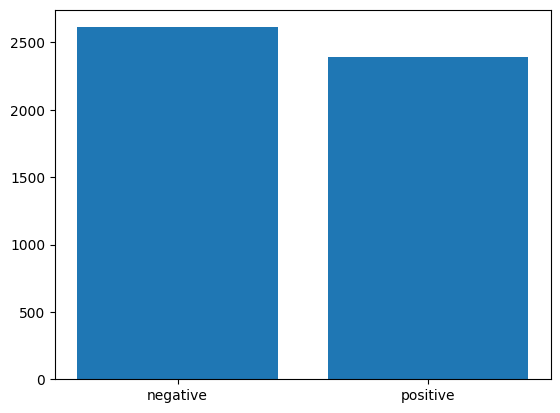

In [15]:
sentiment_count = df.groupby('sentiment').count()
# show number of count of positive and negative
print(sentiment_count)
# Showing the bar plot of positive and negative
plt.bar(sentiment_count.index.values, sentiment_count['text'])

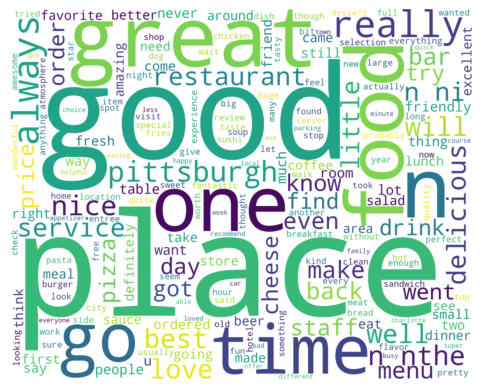

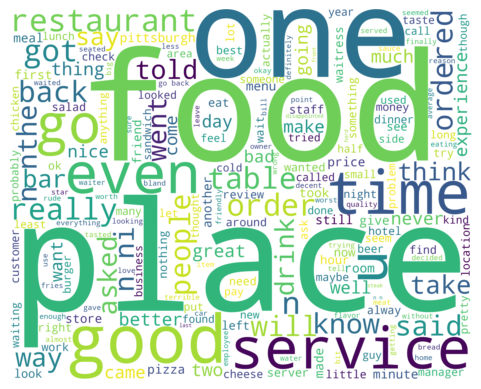

In [16]:
# Visualizing most commonly used words in the negative and positive reviews
from wordcloud import WordCloud

positive_text = df[df['sentiment'] == 'positive']
negative_text = df[df['sentiment'] == 'negative']

txt_positive = " ".join(text.lower() for text in positive_text['text'])
txt_negative = " ".join(text.lower() for text in negative_text['text'])

# Generate a word cloud image
wordcloud_positive = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_positive)
wordcloud_negative = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_negative)

# Display the generated image:
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.show()

plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.show()

In [17]:
'''
This file contains the functions needed to normalize the data from its respective dataset. These are the following steps in the normalization process:
1. Convert emojis to text
2. Remove links
3. Remove hashtags
4. Make all text lowercase
5. Removing repeated characters
6. Removing punctuation repetitions
7. Replacing contractions with their expanded form

References:
- Perform Sentiment Analysis on Twitter data by combining Text Mining and NLP techniques, NLTK and Scikit-Learn
- by Benjamin Termonia
- provided by Udemy Business
'''
import re # Used for regex
import emoji # Used to convert emojis to text

import contractions # Used to expand contractions

import nltk
import ssl # Used to fix SSL error when downloading nltk data

'''
Error handling for nltk download and issue with SSL
Reference: https://stackoverflow.com/questions/38916452/nltk-download-ssl-certificate-verify-failed
    and https://github.com/gunthercox/ChatterBot/issues/930#issuecomment-322111087
'''
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

from nltk.tokenize import word_tokenize
nltk.download('punkt')

import string
from nltk.corpus import stopwords
nltk.download('stopwords')

# Stemming
from nltk.stem import PorterStemmer 
from nltk.stem import LancasterStemmer # more agressive stemming
from nltk.stem import SnowballStemmer # better than porter and newer

# Remove emojis
def convert_emoji_to_text(text):
    text = emoji.demojize(text) # Converting the emoji to their word meaning
    text = text.replace(":"," ") # Replacing the colon symbol with a space
    return text

# Remove links
def remove_links(text, replace_with=""):
    text = re.sub('(http|https):\/\/\S+', replace_with, text) # regex to remove any links starting with http or https
    return text

# Remove hashtags
def remove_hashtags(text, replace_with=""):
    text = re.sub('#+', replace_with, text) # regex to remove any hashtags
    return text


# Make all text lowercase
def lower_case_string(text):
    return text.lower()


# Removing repeated characters
def remove_letter_repetitions(text):
    return re.sub(r'(.)\1+', r'\1\1', text) # regex to remove repeated chars, firstly matches a char which is repeated more than once, then replaces it with the same char twice

# Removing punctuation repetitions
def remove_punctuation_repetitions(text, replace_with=""):
    return re.sub(r'[\?\.\!]+(?=[\?\.\!])', replace_with, text) # regex to remove repeated punctuation, firstly matches a punctuation which is repeated more than once, then replaces it with a single punctuation

'''
Replacing contractions with their expanded form
'''
# Replacing contractions with their full form: e.g I'm -> I am
def replace_contractions(text):
    text = contractions.fix(text) # Using built in method from contractions library
    return text

# Depending if we want to keep punctuation, alphanumeric characters and stopwords we can use the following function with True or False
def custom_tokenization(text, keep_punctuation = False, keep_alphanum = False, keep_stopwords = False):
    stop_words = set(stopwords.words('english')) # Getting the stop words from nltk
    token_list = word_tokenize(text)

    if not keep_punctuation:
        token_list = [token for token in token_list if token not in string.punctuation] # Add only if not in the punctuation list
    if not keep_alphanum:
        token_list = [token for token in token_list if token.isalpha()] # Add only if is a letter
    if not keep_stopwords:
        stop_words = set(stopwords.words('english'))
        stop_words.discard('not') # Remove stop words which are relevant for sentiment analysis from the stop words list !NOTE: Can add more words to be excluded
        token_list = [token for token in token_list if token not in stop_words] # Add only if not in the stop words list

    return token_list

# Function to stem tokens given a stemming algorithm, e.g. porter, lancaster, snowball
def stemming_tokens(tokens, stemmer):
    # depending on the chosen stemmer, we will use the respective stemming algorithm
    if stemmer == 'porter':
        stemmer = PorterStemmer()
    elif stemmer == 'lancaster':
        stemmer = LancasterStemmer()
    elif stemmer == 'snowball':
        stemmer = SnowballStemmer('english')
    else:
        raise ValueError('Stemmer not recognized - please choose between porter, lancaster or snowball.')

    # Stemming the tokens using specified stemmer
    token_list = [stemmer.stem(token) for token in tokens] # Add the new stemmed token to the list
    return token_list

# Function to process the text, removing links, converting emojis to text, removing hashtags, making string lowercase, removing repeated characters and punctuation and replacing contractions
def process_text(text):
    # Removing links and converting emojis to text
    p_txt = remove_links(text)
    p_txt = convert_emoji_to_text(p_txt)

    # Removing hashtags, making string lowercase, removing repeated characters and punctuation and replacing contractions
    p_txt = remove_hashtags(p_txt)
    p_txt = lower_case_string(p_txt)
    p_txt = remove_letter_repetitions(p_txt)
    p_txt = remove_punctuation_repetitions(p_txt)
    p_txt = replace_contractions(p_txt)
    
    # Tokenizing the string
    p_txt = custom_tokenization(p_txt)

    # Stemming the tokens, using the snowball stemmer
    p_txt = stemming_tokens(p_txt, 'snowball')
    return p_txt

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
# apply the process_text function to the tweet_text column
df["tokens"] = df["text"].apply(process_text)

# change sentiment to 1 or 0
df["text_sentiment"] = df["sentiment"].apply(lambda x: 1 if x == "positive" else 0)

In [ ]:
x  = df["tokens"].tolist()
y = df["text_sentiment"].tolist()

In [ ]:
def custom_preprocessor(text):
    return text

def custom_tokenizer(text):
    return text

In [ ]:
corpus = x # corpus is the text tokens of whole dataset

# BAG OF WORDS (CountVectorizer)
def fit_cv(text_corpus):
    cv_vect = CountVectorizer(tokenizer=custom_tokenizer, preprocessor=custom_preprocessor) # Using custom tokenizer and preprocessor

    cv_vect.fit(text_corpus)

    return cv_vect

# TF-IDF (TfidfVectorizer)
def fit_tfidf(text_corpus):
    tf_vect = TfidfVectorizer(preprocessor=custom_preprocessor, tokenizer=custom_tokenizer) # Using custom tokenizer and preprocessor

    tf_vect.fit(text_corpus) # fit the vectorizer on the corpus
    return tf_vect